### Inversion Visualization

In [1]:
# Import necessary dependencies
import pickle
import sys
import numpy as np
import matplotlib as mpl

sys.path.append('..')
from src.inv import *

mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 100.0

#### 1. Load Inversion Results

In [2]:
# Load the saved 2D matrix and metadata
saved_data = np.load("../results/inv_outputs_urban/final_2D_matrix.npz")
vs_2d_matrix_mean = saved_data['vs_matrix_mean']
positions = saved_data['positions']
z_grid = saved_data['z_grid']

# Load the entire list of InversionResult objects back into memory
with open("../results/inv_outputs_urban/all_results_list.pkl", "rb") as f:
    all_results = pickle.load(f)

#### 2. Check Results

=== Station at 244.0m (Index 1) ===
--------------------------------------------------------------------------------
Best model out of 150000 models (5 runs)

Velocity model                                    Model parameters
----------------------------------------          ------------------------------
         d        vp        vs       rho                   d        vs        nu
      [km]    [km/s]    [km/s]   [g/cm3]                [km]    [km/s]       [-]
----------------------------------------          ------------------------------
    0.0052    0.6514    0.3207    1.0000              0.0052    0.3207    0.3400
    0.0274    0.6857    0.3376    1.0000              0.0274    0.3376    0.3400
    0.0250    0.8891    0.4377    1.0000              0.0250    0.4377    0.3400
    0.0349    0.8891    0.4377    1.0000              0.0349    0.4377    0.3400
    1.0000    1.1409    0.5761    1.0000                   -    0.5761    0.3289
----------------------------------------     

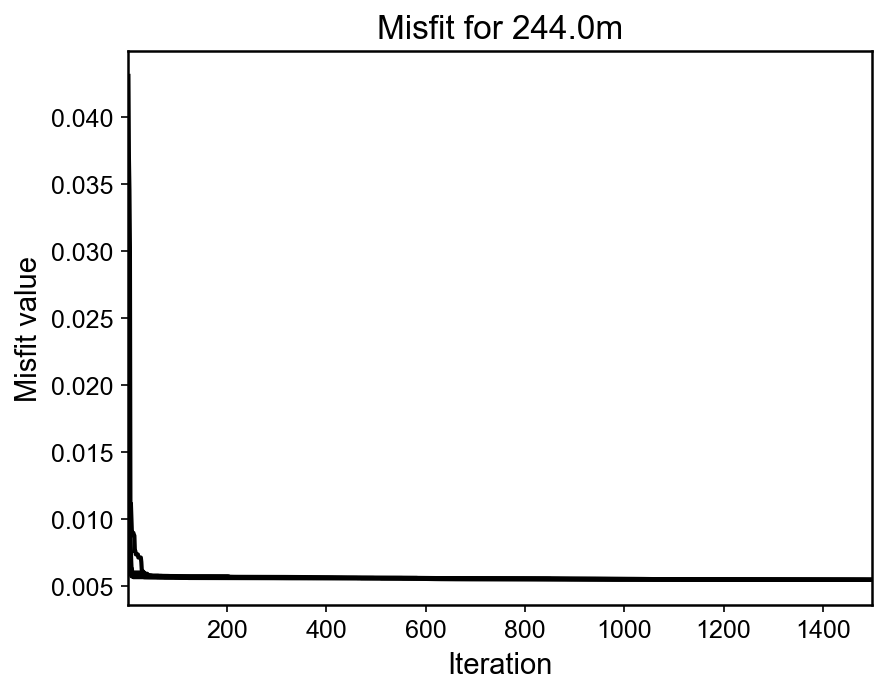

In [3]:
check(all_results, positions, 1)

#### 3. Inspect Every Profile

Plotting curves from 15001 models.


Calculating Curves: 100%|██████████| 15001/15001 [00:05<00:00, 2918.32it/s] 


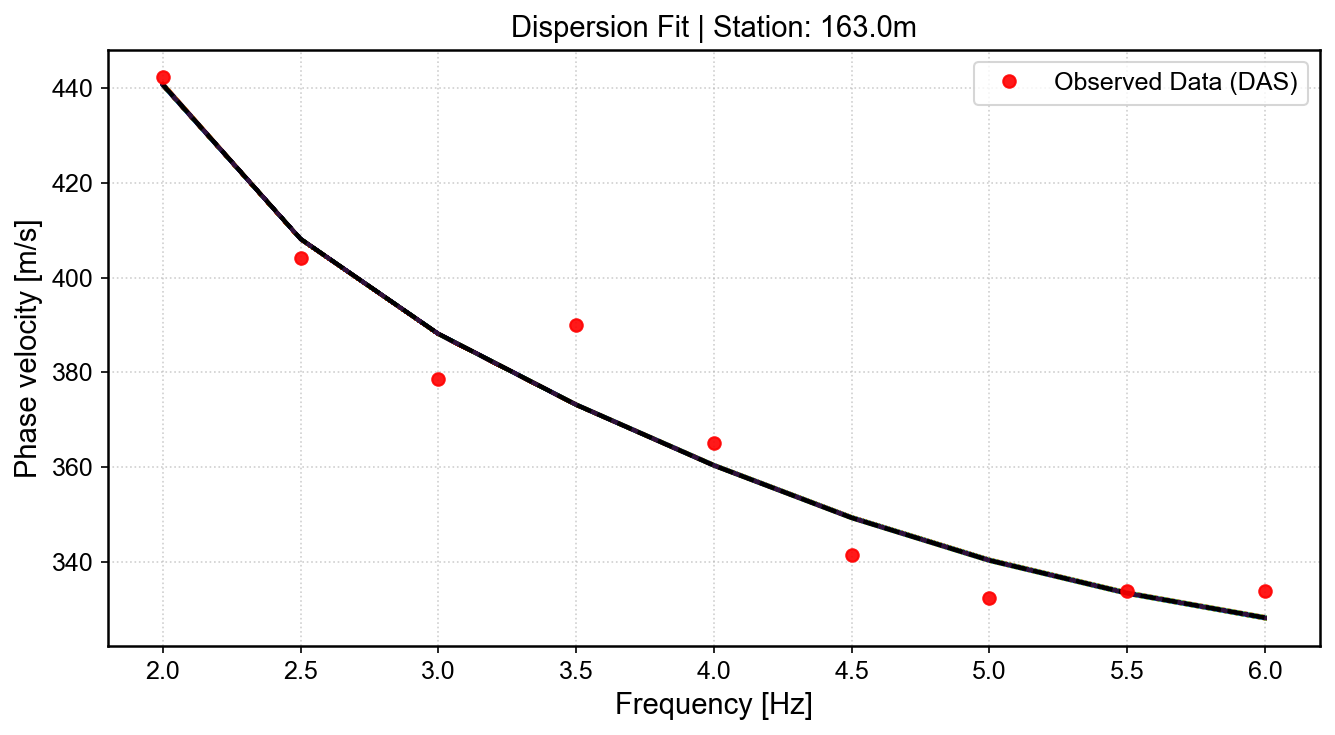

In [4]:
plot_dispersion_fit(all_results, positions, obs_dir = "../results/inv_inputs_urban", index=0)

In [5]:
animate_saved_profiles(positions, img_dir="../results/inv_profiles_urban")

Stitching saved images into an animation...
Loading video player...


Figure successfully saved to: ../results/inv_profiles_urban/contour_2D_profile.png


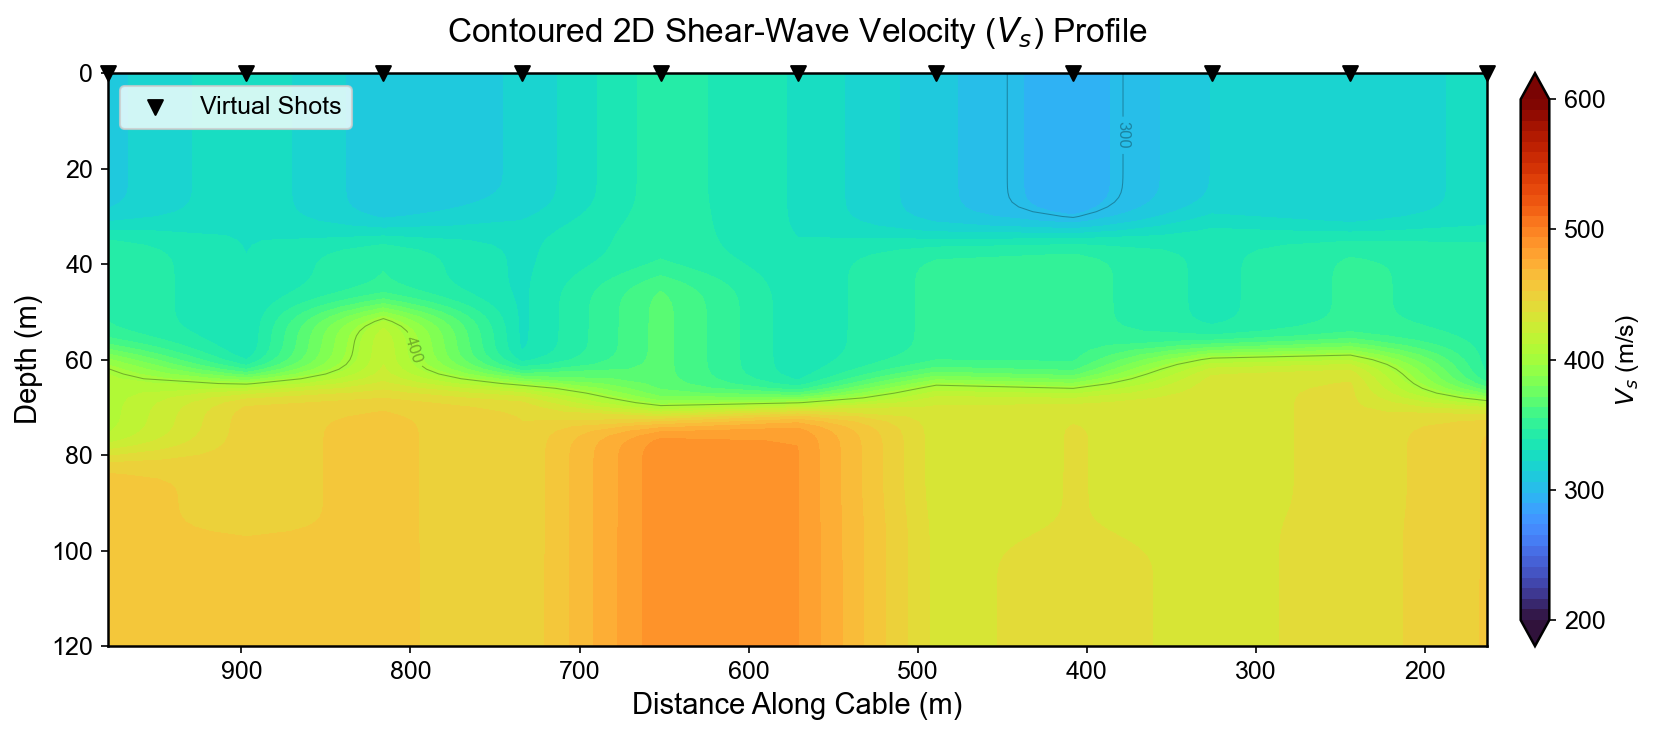

In [8]:
plot_2d_contour_section(positions, z_grid, vs_2d_matrix_mean, max_depth=120, 
                        smooth_sigma=(3, 0), contour=True, x_flip=True,
                        save_path="../results/inv_profiles_urban/contour_2D_profile.png")